In [2]:
# Imports
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl

In [3]:
import sys
!{sys.executable} -m pip install openpyxl


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [4]:
## Load data:
this_path = os.getcwd()
print(this_path)
data_path  = this_path + "/trial_log.xlsx"

pd_data = pd.read_excel(data_path)
agg_res = pd_data.groupby(['policy', 'condition']).sum()
agg_res['success']/20*100

/Users/tamara/Google Drive/act-diffusion-vla-so101/perturbation


policy   condition     
act      distractor        40.0
         lighting          25.0
         nominal           45.0
         novel_color       55.0
         novel_object       5.0
         position_shift     5.0
         slide             70.0
smolvla  distractor        20.0
         lighting          25.0
         nominal           35.0
         novel_color       10.0
         novel_object      10.0
         position_shift     0.0
         slide             45.0
Name: success, dtype: float64

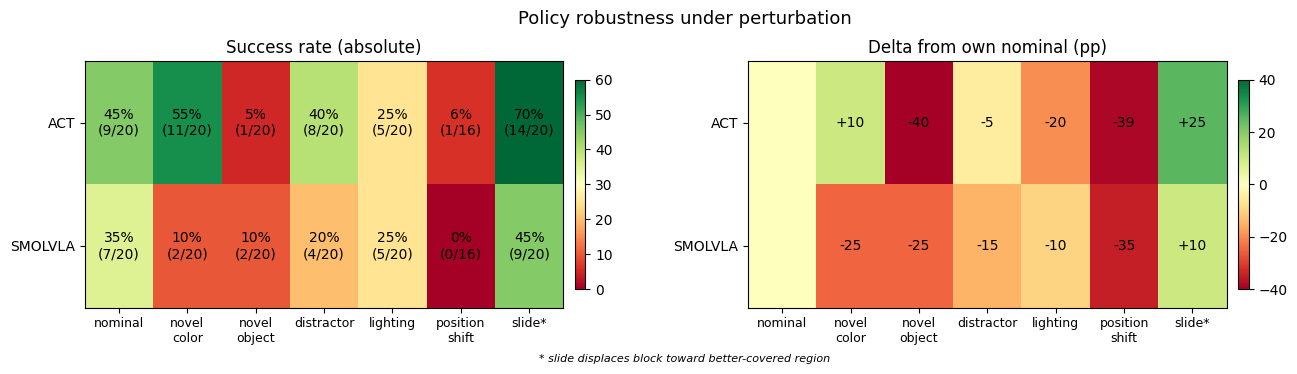

In [15]:
## Plot heatmap on success rate

# ---- config ----------------------------------------------------------------
COND_ORDER = ["nominal", "novel_color", "novel_object", "distractor", "lighting", "position_shift", "slide"]
POLICIES = ["act", "smolvla"]

# ---- rates from the trial log ----------------------------------------------
pd_data["success"] = pd_data["success"].astype(int)

agg = pd_data.groupby(['policy', 'condition'])["success"].agg(["sum", "count"])

def cell(policy, cond):
    s, n = agg.loc[(policy, cond)]
    return s, n

rate = np.zeros((len(POLICIES), len(COND_ORDER)))
label = np.empty_like(rate, dtype=object)
for i, p in enumerate(POLICIES):
    for j, c in enumerate(COND_ORDER):
        s, n = cell(p, c)
        rate[i, j] = 100 * s / n
        label[i, j] = f"{100*s/n:.0f}%\n({s}/{n})"

delta = rate - rate[:, [0]]   

# ---- figure -----------------------------------------------------------------
# fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), facecolor = "white")
# titles = ["Success rate (absolute)", "Delta from own nominal (pp)"]

# for ax, data, title in zip(axes, [rate, delta], titles):
#     if title.startswith("Delta"):
#         v = np.abs(delta).max()
#         im = ax.imshow(data, cmap="RdYlGn", vmin=-v, vmax=v)   # blue=better, red=worse, white=0
#         txt = np.vectorize(lambda x: f"{x:+.0f}")(data)
#         txt[:, 0] = ""                                       # nominal delta is trivially 0
#     else:
#         im = ax.imshow(data, cmap="RdYlGn", vmin=0, vmax=60)
#         txt = label
#     for i in range(data.shape[0]):
#         for j in range(data.shape[1]):
#             ax.text(j, i, txt[i, j], ha="center", va="center", fontsize=10,
#                     color="black" if title.startswith("Success") and data[i, j] < 55 else "black")
#     ax.set_xticks(range(len(COND_ORDER)),
#                   [c.replace("_", "\n") + ("*" if c == "slide" else "") for c in COND_ORDER])
#     ax.set_yticks(range(len(POLICIES)), [p.upper() for p in POLICIES])
#     ax.set_title(title)
#     fig.colorbar(im, ax=ax, shrink=0.8)

# fig.suptitle("Policy robustness under perturbation", fontsize=13, color="black", y=0.98)
# fig.text(0.5, 0.02, "* slide displaces block toward better-covered region ",
#          ha="center", fontsize=8, style="italic")
# # plt.tight_layout()
# plt.subplots_adjust(hspace=0.45, top=0.88, bottom=0.12)
# plt.savefig("robustness_heatmap.png", dpi=200, bbox_inches="tight")
# plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 3.2), facecolor="white")
titles = ["Success rate (absolute)", "Delta from own nominal (pp)"]
for ax, data, title in zip(axes, [rate, delta], titles):
    if title.startswith("Delta"):
        v = np.abs(delta).max()
        im = ax.imshow(data, cmap="RdYlGn", vmin=-v, vmax=v, aspect="auto")
        txt = np.vectorize(lambda x: f"{x:+.0f}")(data)
        txt[:, 0] = ""
    else:
        im = ax.imshow(data, cmap="RdYlGn", vmin=0, vmax=60, aspect="auto")
        txt = label
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, txt[i, j], ha="center", va="center", fontsize=10, color="black")
    ax.set_xticks(range(len(COND_ORDER)),
                  [c.replace("_", "\n") + ("*" if c == "slide" else "") for c in COND_ORDER],
                  fontsize=9)
    ax.set_yticks(range(len(POLICIES)), [p.upper() for p in POLICIES])
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
fig.suptitle("Policy robustness under perturbation", fontsize=13, y=1.04)
fig.text(0.5, -0.06, "* slide displaces block toward better-covered region",
         ha="center", fontsize=8, style="italic")
plt.subplots_adjust(wspace=0.15)
plt.savefig("robustness_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()


In [6]:
# =============================================================================
# Failure taxonomy — robustness grid (frozen before coding pass)
# =============================================================================
TAXONOMY = {
    # ---- targeting failures (where did it think the target was?) ----
    "sought_demo_middle":    "approached/grasped at demo-region middle, ignoring actual target position (anchored to REGION)",
    # "sought_stale_position": "approached target's pre-slide location (slide memorization signature)",
    "no_target_registered":  "empty-table behavior: hovered/wandered, never committed to any object",
    # "sought_distractor":     "approach/grasp directed at sock when block was the target",
    "oscillation":           "stuck cycling start<->middle<->tray without committing",
    # ---- localization-precision failures (found it, landed wrong) ----
    "near_miss":             "at/over the target, marginally off (gripper on top of block, touched it, almost grabbed)",
    "beside_object":         "landed ADJACENT to the target, clearly displaced, typically never over it (anchored to OBJECT)",
    # ---- execution failures (found it, botched the grasp/transport) ----
    "wrong_wrist":           "position ok, wrist orientation wrong for target's actual pose (modal-grasp signature)",
    "tipped_block":          "contact tipped/knocked the target instead of grasping",
    "pushed_block":          "contact pushed target away/out of region/out of view",
    "grasp_slip":            "closed at right spot, couldn't hold (deformable slip)",
    "closed_on_nothing":     "fingers closed on air/edge at roughly right spot",
    "dropped_in_transit":    "secured, then lost between pickup and plate",
    "missed_plate":          "carried and released, rest outside/on rim",
    "block_not_released":    "picked up, never released",
    "post_drop_confusion":   "task completed but policy kept acting as if not (secondary tag on successes)",
    "never_moved":           "arm froze / never approached",
}

# =============================================================================
# Coding: trial_id -> primary label = first DECISIVE failure, from failure notes.
# "same as above/previous" chains inherit the parent label.
# =============================================================================
CODING = {
    # --- act position_shift ---
    2:"pushed_block", 3:"pushed_block", 4:"wrong_wrist", 5:"no_target_registered",
    6:"oscillation", 7:"oscillation", 8:"near_miss", 9:"sought_demo_middle",
    10:"sought_demo_middle", 11:"no_target_registered", 12:"sought_demo_middle",
    13:"no_target_registered", 14:"no_target_registered", 15:"no_target_registered",
    16:"no_target_registered",
    # --- smolvla position_shift ---
    17:"sought_demo_middle", 18:"beside_object", 19:"beside_object",
    20:"beside_object", 21:"beside_object", 22:"beside_object",
    23:"beside_object", 24:"beside_object", 25:"near_miss",
    26:"near_miss", 27:"sought_demo_middle", 28:"sought_demo_middle",
    29:"sought_demo_middle", 30:"sought_demo_middle", 31:"sought_demo_middle",
    32:"sought_demo_middle",
    # --- act novel_color ---
    35:"sought_demo_middle", 36:"sought_demo_middle", 40:"tipped_block",
    42:"tipped_block", 44:"sought_demo_middle", 45:"sought_demo_middle",
    46:"sought_demo_middle", 47:"sought_demo_middle", 50:"pushed_block",
    # --- smolvla novel_color ---
    54:"pushed_block", 55:"near_miss", 56:"tipped_block", 57:"near_miss",
    59:"sought_demo_middle", 60:"tipped_block", 61:"wrong_wrist", 62:"wrong_wrist",
    63:"wrong_wrist", 64:"sought_demo_middle", 65:"sought_demo_middle",
    66:"sought_demo_middle", 67:"sought_demo_middle", 68:"wrong_wrist",
    69:"tipped_block", 70:"wrong_wrist", 71:"wrong_wrist", 72:"no_target_registered",
    # --- act distractor ---
    74:"tipped_block", 76:"tipped_block", 77:"tipped_block", 80:"pushed_block",
    82:"pushed_block", 83:"pushed_block", 84:"oscillation", 85:"oscillation",
    86:"sought_demo_middle", 87:"oscillation", 89:"pushed_block", 90:"pushed_block",
    # --- smolvla distractor ---
    94:"pushed_block", 95:"pushed_block", 96:"pushed_block", 97:"near_miss",
    98:"tipped_block", 99:"beside_object", 100:"pushed_block", 103:"wrong_wrist",
    104:"sought_demo_middle", 105:"sought_demo_middle", 106:"wrong_wrist",
    107:"wrong_wrist", 109:"tipped_block", 110:"pushed_block", 111:"tipped_block",
    112:"beside_object",
    # --- act lighting ---
    115:"pushed_block", 116:"pushed_block", 117:"tipped_block", 119:"pushed_block",
    121:"tipped_block", 122:"tipped_block", 123:"near_miss", 124:"tipped_block",
    125:"sought_demo_middle", 126:"no_target_registered", 127:"no_target_registered",
    129:"pushed_block", 130:"pushed_block", 131:"tipped_block", 132:"tipped_block",
    # --- smolvla lighting ---
    134:"pushed_block", 135:"pushed_block", 136:"pushed_block", 137:"near_miss",
    139:"sought_demo_middle", 140:"pushed_block", 143:"near_miss",
    144:"sought_demo_middle", 145:"sought_demo_middle", 146:"beside_object",
    147:"beside_object", 149:"tipped_block", 150:"pushed_block",
    151:"near_miss", 152:"near_miss",
    # --- act novel_object ---
    153:"beside_object", 154:"beside_object", 155:"beside_object",
    156:"no_target_registered", 157:"no_target_registered", 159:"sought_demo_middle",
    160:"sought_demo_middle", 161:"sought_demo_middle", 162:"sought_demo_middle",
    163:"sought_demo_middle", 164:"sought_demo_middle", 165:"sought_demo_middle",
    166:"sought_demo_middle", 167:"sought_demo_middle", 168:"no_target_registered",
    169:"no_target_registered", 170:"no_target_registered", 171:"no_target_registered",
    172:"no_target_registered",
    # --- smolvla novel_object ---
    175:"tipped_block", 176:"tipped_block", 177:"tipped_block", 178:"grasp_slip",
    179:"pushed_block", 180:"grasp_slip", 181:"pushed_block", 182:"pushed_block",
    183:"wrong_wrist", 184:"beside_object", 185:"beside_object",
    186:"beside_object", 187:"beside_object", 188:"wrong_wrist",
    189:"wrong_wrist", 190:"wrong_wrist", 191:"beside_object", 192:"grasp_slip",
    # --- act slide ---
    198:"sought_stale_position", 203:"sought_stale_position", 206:"tipped_block",
    207:"tipped_block", 208:"tipped_block", 210:"pushed_block",
    # --- smolvla slide ---
    214:"pushed_block", 216:"pushed_block", 221:"pushed_block", 223:"tipped_block",
    224:"pushed_block", 225:"wrong_wrist", 226:"wrong_wrist", 227:"wrong_wrist",
    229:"wrong_wrist", 230:"tipped_block", 231:"pushed_block",
    # --- act nominal ---
    235:"near_miss", 237:"tipped_block", 239:"near_miss",
    240:"pushed_block", 244:"beside_object", 245:"beside_object",
    246:"sought_demo_middle", 247:"sought_demo_middle", 249:"sought_demo_middle",
    250:"near_miss",
    # --- smolvla nominal ---
    255:"near_miss", 257:"beside_object", 259:"tipped_block",
    260:"block_not_released", 261:"pushed_block", 262:"pushed_block",
    264:"sought_demo_middle", 265:"sought_demo_middle", 266:"sought_demo_middle",
    267:"sought_demo_middle", 269:"pushed_block", 270:"pushed_block",
}

# Successes carrying the post-drop-confusion tag (secondary; scored 1 regardless)
POST_DROP_CONFUSION = [93, 101, 102, 120, 158, 173, 174]

# Needs the targeted video pass (note underdetermines the category);
# 242/271 are failures with EMPTY notes -> video is the only source
REVIEW = [2, 8, 18, 84, 85, 99, 112, 153, 154, 155, 168, 169, 170, 198, 203,
          242, 271]

# =============================================================================
# Coding: trial_id -> primary label = first DECISIVE failure, from failure notes.
# FINAL ASSIGNMENTS AFTER I REVIEWED THEM ONE BY ONE
# =============================================================================
CODING = {
    # --- act position_shift ---
    2:"pushed_block", 3:"pushed_block", 4:"wrong_wrist", 5:"no_target_registered",
    6:"oscillation", 7:"oscillation", 8:"pushed_block", 9:"sought_demo_middle",
    10:"sought_demo_middle", 11:"oscillation", 12:"sought_demo_middle",
    13:"no_target_registered", 14:"no_target_registered", 15:"no_target_registered",
    16:"no_target_registered",
    # --- smolvla position_shift ---
    17:"sought_demo_middle", 18:"beside_object", 19:"beside_object",
    20:"beside_object", 21:"beside_object", 22:"beside_object",
    23:"beside_object", 24:"beside_object", 25:"near_miss",
    26:"near_miss", 27:"sought_demo_middle", 28:"sought_demo_middle",
    29:"sought_demo_middle", 30:"sought_demo_middle", 31:"sought_demo_middle",
    32:"sought_demo_middle",
    # --- act novel_color ---
    35:"sought_demo_middle", 36:"sought_demo_middle", 40:"tipped_block",
    42:"tipped_block", 44:"sought_demo_middle", 45:"sought_demo_middle",
    46:"sought_demo_middle", 47:"sought_demo_middle", 50:"pushed_block",
    # --- smolvla novel_color ---
    54:"pushed_block", 55:"near_miss", 56:"tipped_block", 57:"near_miss",
    59:"sought_demo_middle", 60:"tipped_block", 61:"wrong_wrist", 62:"wrong_wrist",
    63:"wrong_wrist", 64:"sought_demo_middle", 65:"sought_demo_middle",
    66:"sought_demo_middle", 67:"sought_demo_middle", 68:"wrong_wrist",
    69:"tipped_block", 70:"wrong_wrist", 71:"wrong_wrist", 72:"no_target_registered",
    # --- act distractor ---
    74:"tipped_block", 76:"tipped_block", 77:"tipped_block", 80:"pushed_block",
    82:"pushed_block", 83:"pushed_block", 84:"oscillation", 85:"oscillation",
    86:"sought_demo_middle", 87:"oscillation", 89:"pushed_block", 90:"pushed_block",
    # --- smolvla distractor ---
    94:"pushed_block", 95:"pushed_block", 96:"pushed_block", 97:"near_miss",
    98:"tipped_block", 99:"beside_object", 100:"pushed_block", 103:"wrong_wrist",
    104:"sought_demo_middle", 105:"sought_demo_middle", 106:"wrong_wrist",
    107:"wrong_wrist", 109:"pushed_block", 110:"pushed_block", 111:"pushed_block",
    112:"beside_object",
    # --- act lighting ---
    115:"pushed_block", 116:"pushed_block", 117:"tipped_block", 119:"pushed_block",
    121:"tipped_block", 122:"tipped_block", 123:"near_miss", 124:"tipped_block",
    125:"sought_demo_middle", 126:"no_target_registered", 127:"no_target_registered",
    129:"pushed_block", 130:"pushed_block", 131:"tipped_block", 132:"tipped_block",
    # --- smolvla lighting ---
    134:"pushed_block", 135:"pushed_block", 136:"near_miss", 137:"near_miss",
    139:"sought_demo_middle", 140:"pushed_block", 143:"near_miss",
    144:"sought_demo_middle", 145:"sought_demo_middle", 146:"beside_object",
    147:"beside_object", 149:"tipped_block", 150:"pushed_block",
    151:"near_miss", 152:"near_miss",
    # --- act novel_object ---
    153:"beside_object", 154:"beside_object", 155:"beside_object",
    156:"no_target_registered", 157:"no_target_registered", 159:"no_target_registered",
    160:"no_target_registered", 161:"no_target_registered", 162:"no_target_registered",
    163:"no_target_registered", 164:"no_target_registered", 165:"no_target_registered",
    166:"no_target_registered", 167:"no_target_registered", 168:"no_target_registered",
    169:"no_target_registered", 170:"no_target_registered", 171:"no_target_registered",
    172:"no_target_registered",
    # --- smolvla novel_object ---
    175:"near_miss", 176:"near_miss", 177:"near_miss", 178:"grasp_slip",
    179:"beside_object", 180:"grasp_slip", 181:"near_miss", 182:"near_miss",
    183:"grasp_slip", 184:"beside_object", 185:"beside_object",
    186:"beside_object", 187:"beside_object", 188:"near_miss",
    189:"near_miss", 190:"grasp_slip", 191:"beside_object", 192:"grasp_slip",
    # --- act slide ---
    198:"sought_demo_middle", 203:"sought_demo_middle", 206:"tipped_block",
    207:"tipped_block", 208:"tipped_block", 210:"pushed_block",
    # --- smolvla slide ---
    214:"pushed_block", 216:"pushed_block", 221:"pushed_block", 223:"tipped_block",
    224:"pushed_block", 225:"wrong_wrist", 226:"wrong_wrist", 227:"wrong_wrist",
    229:"wrong_wrist", 230:"tipped_block", 231:"pushed_block",
    # --- act nominal ---
    235:"beside_object", 237:"tipped_block", 239:"beside_object",
    240:"tipped_block", 242:"beside_object", 244:"beside_object", 245:"beside_object",
    246:"sought_demo_middle", 247:"sought_demo_middle", 249:"sought_demo_middle",
    250:"beside_object",
    # --- smolvla nominal ---
    255:"near_miss", 257:"beside_object", 259:"tipped_block",
    260:"block_not_released", 261:"pushed_block", 262:"pushed_block",
    264:"sought_demo_middle", 265:"sought_demo_middle", 266:"sought_demo_middle",
    267:"sought_demo_middle", 269:"pushed_block", 270:"pushed_block", 271:"beside_object",
}

# =============================================================================
# Apply + validate + tables
# =============================================================================
df = pd.read_excel(data_path)
df["taxonomy"] = df["trial_id"].map(CODING)

bad = set(CODING.values()) - set(TAXONOMY)
assert not bad, f"labels not in TAXONOMY: {bad}"

fails = df[df["success"] == 0]
uncoded = fails[fails["taxonomy"].isna()]
print(f"failures: {len(fails)} | coded: {len(fails)-len(uncoded)} | uncoded: {uncoded['trial_id'].tolist()}")

mislabeled = df[(df["success"] == 1) & df["taxonomy"].notna()]
assert mislabeled.empty, f"successes carrying failure labels: {mislabeled['trial_id'].tolist()}"

for cond in ["nominal", "novel_color", "novel_object", "distractor",
             "lighting", "position_shift", "slide"]:
    sub = fails[fails["condition"] == cond]
    print(f"\n=== {cond} ===")
    print(sub.groupby(["policy", "taxonomy"]).size().unstack(fill_value=0).T)

print("\n=== overall by policy ===")
print(fails.groupby(["policy", "taxonomy"]).size().unstack(fill_value=0).T)

print("\n=== overall by policy (excl. position_shift) ===")
sub = fails[fails["condition"] != "position_shift"]
print(sub.groupby(["policy", "taxonomy"]).size().unstack(fill_value=0).T)

# optional: persist the coded log next to the raw one
# df.to_csv("trial_log_coded.csv", index=False)

failures: 194 | coded: 194 | uncoded: []

=== nominal ===
policy              act  smolvla
taxonomy                        
beside_object         6        2
block_not_released    0        1
near_miss             0        1
pushed_block          0        4
sought_demo_middle    3        4
tipped_block          2        1

=== novel_color ===
policy                act  smolvla
taxonomy                          
near_miss               0        2
no_target_registered    0        1
pushed_block            1        1
sought_demo_middle      6        5
tipped_block            2        3
wrong_wrist             0        6

=== novel_object ===
policy                act  smolvla
taxonomy                          
beside_object           3        6
grasp_slip              0        5
near_miss               0        7
no_target_registered   16        0

=== distractor ===
policy              act  smolvla
taxonomy                        
beside_object         0        2
near_miss             0   

In [7]:
# =============================================================================
# Success taxonomy — how did the successes happen?
# Primary mode = attempt structure; orthogonal tags capture qualifiers, since
# one success can be "2nd attempt" AND "tipped on pickup" AND "block displaced".
# =============================================================================
SUCCESS_MODES = {
    "clean_first":  "first attempt, no complications noted (default for empty note)",
    "tipped_first": "first attempt, but tipped/knocked the target during pickup",
    "second_attempt": "succeeded on the 2nd attempt",
    "third_plus":   "succeeded on the 3rd or later attempt / 'multiple tries'",
}
SUCCESS_TAGS = {
    "clean":          "no qualifiers — pickup looked good on first try",
    "tipped":         "tipped the target on the way to success (only for modes other than tipped_first)",
    "displaced_first":"earlier attempt pushed/dragged target to a new spot (usually toward middle) before success",
    "post_drop_confusion": "completed the task but kept acting as if not done",
    "marginal":       "scrappy success: edge grasp, near-loss, or off-center placement in plate",
    "recovered_drop": "had it, dropped it, re-grasped and finished",
}

# trial_id -> mode (successes NOT listed here default to clean_first)
SUCCESS_MODE = {
    1:"third_plus", 34:"second_attempt", 37:"second_attempt", 39:"third_plus",
    49:"third_plus", 51:"second_attempt", 53:"tipped_first", 75:"third_plus",
    79:"third_plus", 91:"second_attempt", 92:"second_attempt", 93:"tipped_first",
    128:"tipped_first", 133:"tipped_first", 138:"tipped_first", 141:"tipped_first",
    194:"second_attempt", 195:"second_attempt", 196:"third_plus",
    200:"second_attempt", 201:"second_attempt", 205:"third_plus",
    212:"second_attempt", 213:"tipped_first", 215:"tipped_first",
    217:"second_attempt", 219:"second_attempt", 220:"second_attempt",
    232:"second_attempt", 236:"tipped_first", 243:"third_plus",
    248:"second_attempt", 251:"second_attempt", 254:"second_attempt",
    256:"second_attempt",
}

# trial_id -> list of tags
SUCCESS_TAG = {
    1:["displaced_first"], 34:["displaced_first"], 37:["displaced_first"],
    39:["displaced_first"], 49:["displaced_first"], 51:["displaced_first"],
    53:["tipped"], 75:["displaced_first"], 79:["tipped","displaced_first"],
    92:["tipped"], 93:["tipped","post_drop_confusion"],
    101:["post_drop_confusion"], 102:["post_drop_confusion"],
    120:["marginal","post_drop_confusion"], 158:["post_drop_confusion"],
    173:["post_drop_confusion"], 174:["post_drop_confusion"],
    194:["tipped"], 196:["tipped"], 201:["tipped"], 205:["displaced_first"],
    219:["tipped"], 220:["recovered_drop"], 232:["displaced_first"],
    236:["tipped"], 241:["marginal"], 243:["displaced_first"],
    248:["tipped"], 252:["marginal"], 256:["tipped","displaced_first"],
}

SUCCESS_REVIEW = [217, 254, 256]   # attempt count ambiguous from note alone


## AFTER REVIEW CHECKING ALL ASIGNMENTS ONE BY ONE:
# trial_id -> mode
SUCCESS_MODE = {
    1:"third_plus", 33: "clean_first",  34:"second_attempt", 37:"second_attempt", 38: "clean_first", 39:"third_plus",
    41:"clean_first", 43:"clean_first", 48:"clean_first", 49:"third_plus", 51:"second_attempt", 52:"clean_first", 
    53:"tipped_first", 58:"clean_first", 73:"clean_first", 75:"third_plus", 78:"clean_first", 79:"third_plus", 
    81:"clean_first", 88:"clean_first", 91:"second_attempt", 92:"second_attempt", 93:"tipped_first",
    101:"clean_first", 102:"clean_first", 108:"clean_first", 113:"clean_first", 114:"clean_first", 118:"clean_first",
    120:"clean_first", 128:"tipped_first", 133:"tipped_first", 138:"tipped_first", 141:"tipped_first", 142:"clean_first",
    148:"clean_first", 158:"clean_first", 173:"clean_first", 174:"clean_first", 193:"clean_first",
    194:"second_attempt", 195:"second_attempt", 196:"third_plus", 197:"clean_first", 199:"clean_first",
    200:"second_attempt", 201:"second_attempt", 202:"clean_first", 204:"clean_first", 205:"third_plus", 209:"clean_first",
    211:"clean_first", 212:"second_attempt", 213:"tipped_first", 215:"tipped_first",
    217:"clean_first", 218:"clean_first", 219:"second_attempt", 220:"second_attempt", 222:"clean_first", 228:"clean_first",
    232:"second_attempt", 233:"clean_first", 234:"clean_first", 236:"tipped_first", 238:"clean_first", 241:"clean_first", 
    243:"third_plus", 248:"second_attempt", 251:"second_attempt", 252:"second_attempt", 
    253:"clean_first", 254:"second_attempt", 256:"second_attempt", 258:"clean_first", 263:"clean_first", 268:"clean_first", 
    272:"clean_first",
}


# trial_id -> list of tags
SUCCESS_TAG = {
    1:["displaced_first"], 33:["clean"], 34:["displaced_first"], 37:["displaced_first"],
    38:["clean"], 39:["displaced_first"],
    41:["clean"], 43:["clean"], 48:["clean"], 49:["displaced_first"], 51:["displaced_first"], 52:["clean"],
    53:["clean"], 58:["clean"], 73:["clean"], 75:["displaced_first"], 78:["clean"], 79:["tipped","displaced_first"],
    81:["clean"], 88:["clean"], 91:["displaced_first"], 92:["tipped"], 93:["post_drop_confusion"],
    101:["post_drop_confusion"], 102:["post_drop_confusion"], 108:["clean"], 113:["clean"], 114:["clean"], 118:["clean"],
    120:["marginal","post_drop_confusion"], 128:["tipped"], 133:["tipped"], 138:["tipped"], 141:["tipped"], 142:["clean"],
    148:["clean"], 158:["post_drop_confusion"], 173:["post_drop_confusion"], 174:["post_drop_confusion"], 193:["clean"],
    194:["tipped"], 195:["displaced_first"], 196:["tipped"], 197:["clean"], 199:["clean"],
    200:["displaced_first"], 201:["tipped"], 202:["clean"], 204:["clean"], 205:["displaced_first"], 209:["clean"],
    211:["clean"], 212:["displaced_first"], 213:["tipped"], 215:["tipped"],
    217:["post_drop_confusion"], 218:["clean"], 219:["tipped"], 220:["recovered_drop"], 222:["clean"], 228:["clean"],
    232:["displaced_first"], 233:["clean"], 234:["clean"], 236:["tipped"], 238:["clean"], 241:["marginal"],
    243:["displaced_first"], 248:["tipped"], 251:["displaced_first"], 252:["marginal"],
    253:["clean"], 254:["displaced_first"], 256:["tipped","displaced_first"], 258:["clean"], 263:["clean"], 268:["clean"],
    272:["clean"],
}

# =============================================================================
# Apply + validate + tables
# =============================================================================
df = pd.read_excel(data_path)     # adjust to your path variable
succ = df[df["success"] == 1].copy()
succ["mode"] = succ["trial_id"].map(SUCCESS_MODE).fillna("clean_first")

bad = set(SUCCESS_MODE.values()) - set(SUCCESS_MODES)
assert not bad, f"modes not in SUCCESS_MODES: {bad}"
assert set(SUCCESS_MODE) <= set(succ["trial_id"]), \
    f"modes assigned to non-successes: {set(SUCCESS_MODE) - set(succ['trial_id'])}"
assert set(SUCCESS_TAG) <= set(succ["trial_id"]), \
    f"tags assigned to non-successes: {set(SUCCESS_TAG) - set(succ['trial_id'])}"

print(f"successes: {len(succ)}")
for cond in ["nominal", "novel_color", "novel_object", "distractor",
             "lighting", "position_shift", "slide"]:
    sub = succ[succ["condition"] == cond]
    if sub.empty:
        continue
    print(f"\n=== {cond} ===")
    print(sub.groupby(["policy", "mode"]).size().unstack(fill_value=0).T)

print("\n=== overall by policy ===")
print(succ.groupby(["policy", "mode"]).size().unstack(fill_value=0).T)

print("\n=== clean-first-try rate (clean_first / successes) ===")
tot = succ.groupby("policy").size()
clean = succ[succ["mode"] == "clean_first"].groupby("policy").size()
print((clean / tot).round(2))

print("\n=== tag counts by policy ===")
tag_rows = [(r["policy"], t) for _, r in succ.iterrows()
            for t in SUCCESS_TAG.get(r["trial_id"], [])]
print(pd.DataFrame(tag_rows, columns=["policy", "tag"]).value_counts().unstack(0, fill_value=0))

successes: 78

=== nominal ===
policy          act  smolvla
mode                        
clean_first       4        5
second_attempt    3        2
third_plus        1        0
tipped_first      1        0

=== novel_color ===
policy          act  smolvla
mode                        
clean_first       6        1
second_attempt    3        0
third_plus        2        0
tipped_first      0        1

=== novel_object ===
policy       act  smolvla
mode                     
clean_first    1        2

=== distractor ===
policy          act  smolvla
mode                        
clean_first       4        3
second_attempt    2        0
third_plus        2        0
tipped_first      0        1

=== lighting ===
policy        act  smolvla
mode                      
clean_first     4        2
tipped_first    1        3

=== position_shift ===
policy      act
mode           
third_plus    1

=== slide ===
policy          act  smolvla
mode                        
clean_first       7        4
second

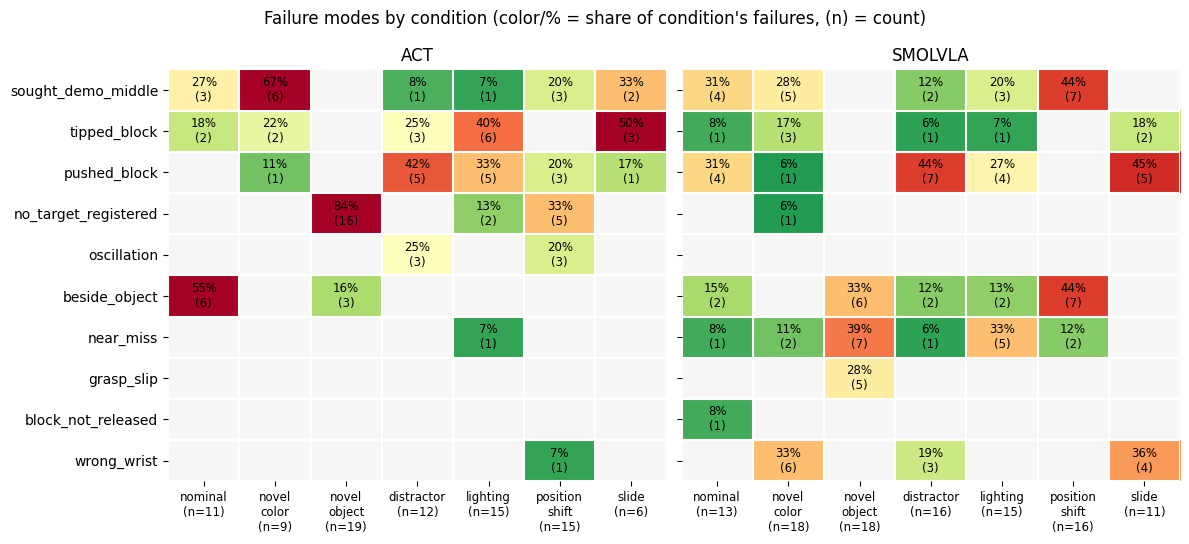

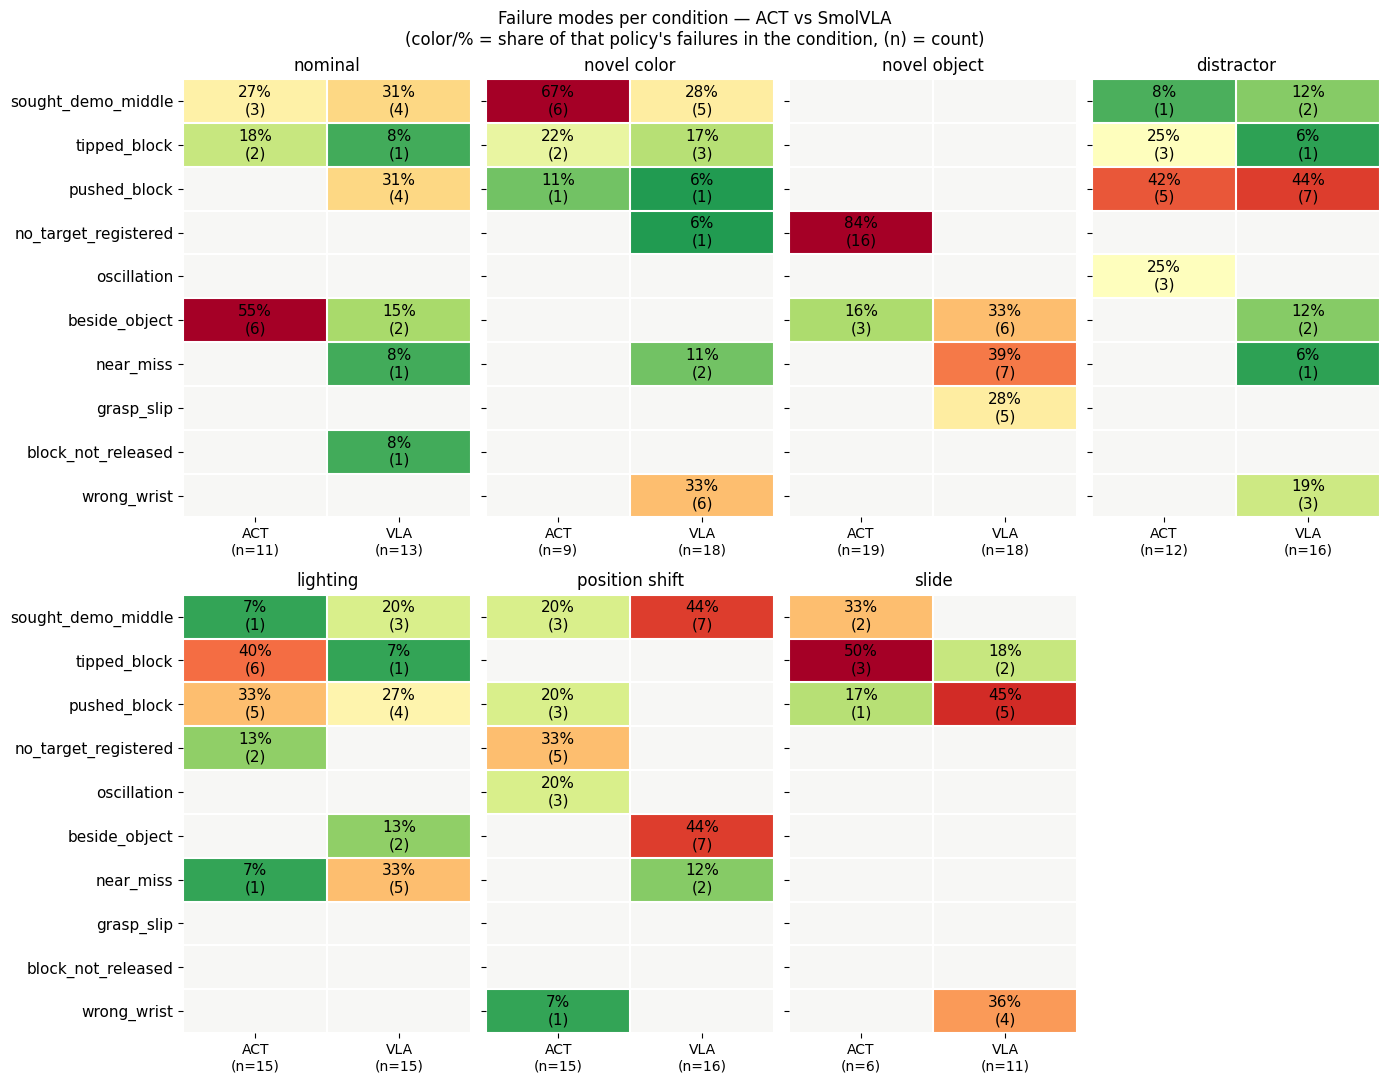

In [8]:
# shared: masked colormap — cells with ZERO failures render near-white

CONDS = COND_ORDER
ROWS_F = ["sought_demo_middle", "tipped_block", "pushed_block",
          "no_target_registered", "oscillation",
          "beside_object", "near_miss", "grasp_slip", "block_not_released",
          "wrong_wrist"]

CMAP = plt.get_cmap("RdYlGn_r").copy()
CMAP.set_bad("#f7f7f5")

def masked(share_df):
    a = share_df.fillna(0).to_numpy()
    return np.ma.masked_where(a == 0, a)

def annotate(ax, counts, share, fontsize=10):
    """% of column, with raw count underneath."""
    for i in range(counts.shape[0]):
        for j in range(counts.shape[1]):
            c = counts.iloc[i, j]
            if c:
                ax.text(j, i, f"{share.iloc[i, j]*100:.0f}%\n({int(c)})",
                        ha="center", va="center", fontsize=fontsize, color="black")

def panel_data(sub, rows):
    counts = sub.groupby(["condition", "taxonomy"]).size().unstack(fill_value=0)
    counts = counts.reindex(index=CONDS, columns=rows, fill_value=0).T   # rows x conds
    share = counts / counts.sum(axis=0).replace(0, np.nan)
    return counts, share

# ---------- Figure 1: per-policy fingerprint ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), facecolor="white")
for ax, pol in zip(axes, ["act", "smolvla"]):
    counts, share = panel_data(fails[fails["policy"] == pol], ROWS_F)
    ax.imshow(masked(share), cmap=CMAP, vmin=0, vmax=0.5, aspect="auto")
    annotate(ax, counts, share, fontsize=8.5)
    n_per_cond = counts.sum(axis=0)
    ax.set_xticks(range(len(CONDS)),
                  [f"{c.replace('_', chr(10))}\n(n={int(n_per_cond.iloc[j])})"
                   for j, c in enumerate(CONDS)], fontsize=8.5)
    ax.set_yticks(range(len(ROWS_F)), ROWS_F if pol == "act" else [""] * len(ROWS_F), fontsize=10)
    ax.set_xticks(np.arange(-0.5, len(CONDS)), minor=True)
    ax.set_yticks(np.arange(-0.5, len(ROWS_F)), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", length=0)
    ax.set_title(pol.upper(), fontsize=12)
    ax.spines[:].set_visible(False)
fig.suptitle("Failure modes by condition (color/% = share of condition's failures, (n) = count)",
             fontsize=12)
plt.tight_layout()
plt.savefig("failure_modes_by_policy.png", dpi=200, bbox_inches="tight")
plt.show()

# ---------- Figure 2: per-condition panels, 2 rows, zeros near-white ----------
fig, axes = plt.subplots(2, 4, figsize=(14, 11), facecolor="white")
axes = axes.ravel()
for k, cond in enumerate(CONDS):
    ax = axes[k]
    sub = fails[fails["condition"] == cond]
    counts = sub.groupby(["taxonomy", "policy"]).size().unstack(fill_value=0)
    counts = counts.reindex(index=ROWS_F, columns=["act", "smolvla"], fill_value=0)
    share = counts / counts.sum(axis=0).replace(0, np.nan)
    ax.imshow(masked(share), cmap=CMAP, vmin=0, vmax=0.5, aspect="auto")
    annotate(ax, counts, share, fontsize=11)
    ax.set_xticks([0, 1],
                  [f"ACT\n(n={int(counts['act'].sum())})",
                   f"VLA\n(n={int(counts['smolvla'].sum())})"], fontsize=10)
    show_labels = (k % 4 == 0)
    ax.set_yticks(range(len(ROWS_F)), ROWS_F if show_labels else [""] * len(ROWS_F), fontsize=11)
    ax.set_xticks(np.arange(-0.5, 2), minor=True)
    ax.set_yticks(np.arange(-0.5, len(ROWS_F)), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", length=0)
    ax.set_title(cond.replace("_", " "), fontsize=12)
    ax.spines[:].set_visible(False)
axes[7].axis("off")
fig.suptitle("Failure modes per condition — ACT vs SmolVLA\n"
             "(color/% = share of that policy's failures in the condition, (n) = count)",
             fontsize=12)
plt.tight_layout()
plt.savefig("failure_modes_per_condition.png", dpi=200, bbox_inches="tight")
plt.show()

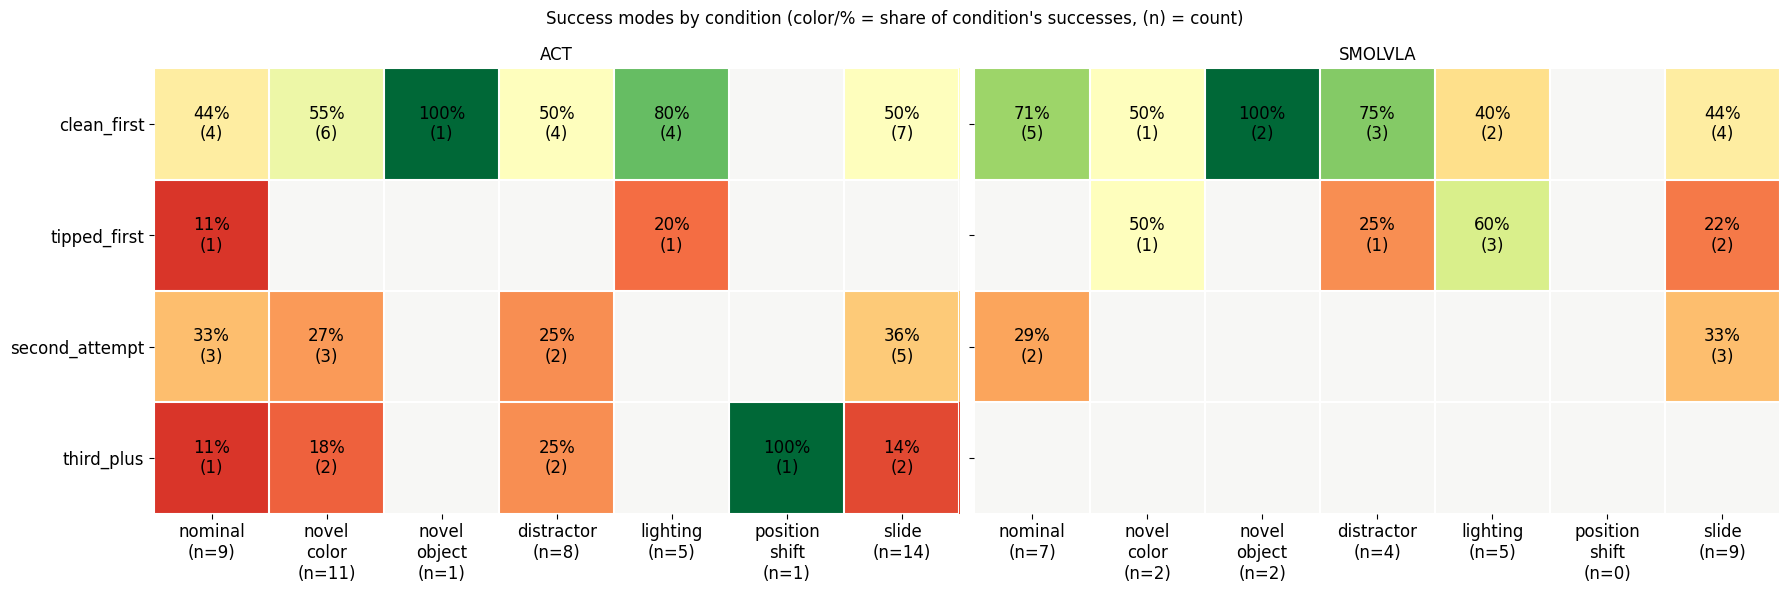

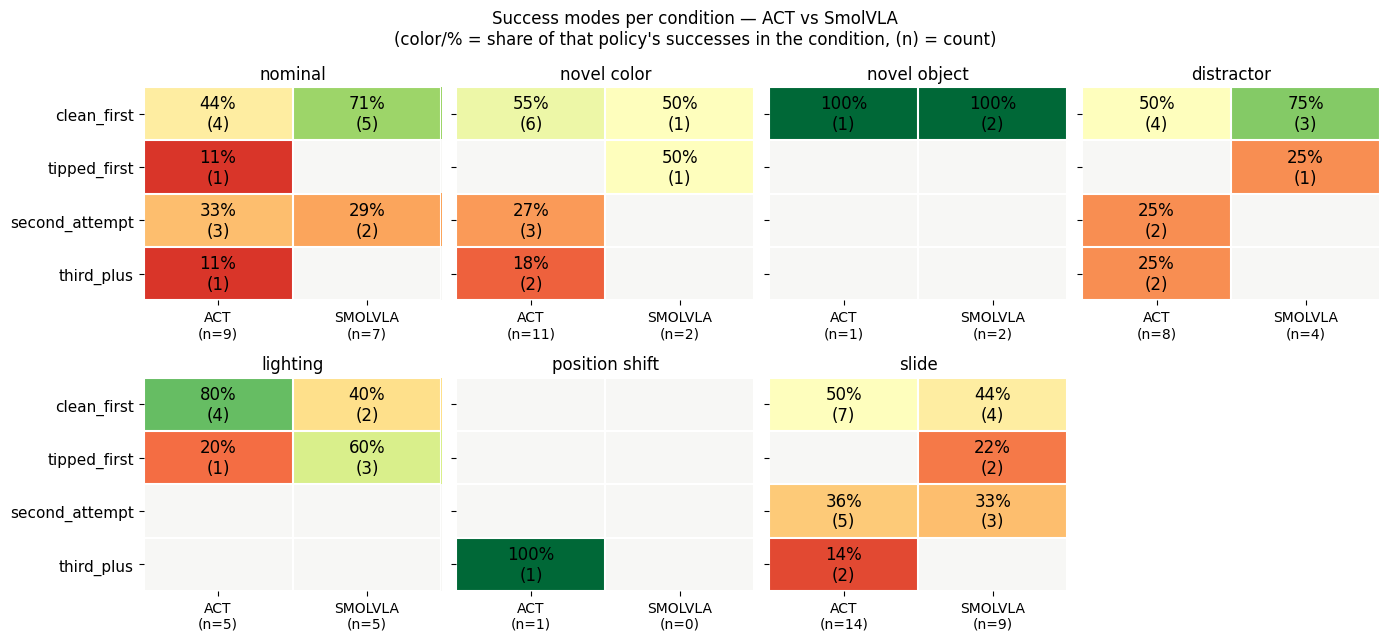

In [11]:
# ================= Success-mode figures (same conventions, green = good) =====
ROWS_S = ["clean_first", "tipped_first", "second_attempt", "third_plus"]
CMAP_S = plt.get_cmap("RdYlGn").copy()      # unreversed: high share = green
CMAP_S.set_bad("#f7f7f5")

def panel_data_s(sub):
    counts = sub.groupby(["condition", "mode"]).size().unstack(fill_value=0)
    counts = counts.reindex(index=CONDS, columns=ROWS_S, fill_value=0).T   # rows x conds
    share = counts / counts.sum(axis=0).replace(0, np.nan)
    return counts, share

def annotate(ax, counts, share, fontsize=8.5):
    """% of column, with raw count underneath."""
    for i in range(counts.shape[0]):
        for j in range(counts.shape[1]):
            c = counts.iloc[i, j]
            if c:
                ax.text(j, i, f"{share.iloc[i, j]*100:.0f}%\n({int(c)})",
                        ha="center", va="center", fontsize=fontsize, color="black")

# ---------- Figure S1: per-policy success fingerprint ----------
fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor="white")
for ax, pol in zip(axes, ["act", "smolvla"]):
    counts, share = panel_data_s(succ[succ["policy"] == pol])
    ax.imshow(masked(share), cmap=CMAP_S, vmin=0, vmax=1, aspect="auto")
    annotate(ax, counts, share, fontsize=12)
    n_per_cond = counts.sum(axis=0)
    ax.set_xticks(range(len(CONDS)),
                  [f"{c.replace('_', chr(10))}\n(n={int(n_per_cond.iloc[j])})"
                   for j, c in enumerate(CONDS)], fontsize=12)
    ax.set_yticks(range(len(ROWS_S)), ROWS_S if pol == "act" else [""] * len(ROWS_S), fontsize=12)
    ax.set_xticks(np.arange(-0.5, len(CONDS)), minor=True)
    ax.set_yticks(np.arange(-0.5, len(ROWS_S)), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", length=0)
    ax.set_title(pol.upper(), fontsize=12)
    ax.spines[:].set_visible(False)
fig.suptitle("Success modes by condition (color/% = share of condition's successes, (n) = count)",
             fontsize=12)
plt.tight_layout()
plt.savefig("success_modes_by_policy.png", dpi=200, bbox_inches="tight")
plt.show()

# ---------- Figure S2: per-condition panels, 2 rows ----------
fig, axes = plt.subplots(2, 4, figsize=(14, 6.5), facecolor="white")
axes = axes.ravel()
for k, cond in enumerate(CONDS):
    ax = axes[k]
    sub = succ[succ["condition"] == cond]
    counts = sub.groupby(["mode", "policy"]).size().unstack(fill_value=0)
    counts = counts.reindex(index=ROWS_S, columns=["act", "smolvla"], fill_value=0)
    share = counts / counts.sum(axis=0).replace(0, np.nan)
    ax.imshow(masked(share), cmap=CMAP_S, vmin=0, vmax=1, aspect="auto")
    annotate(ax, counts, share, fontsize=12)
    ax.set_xticks([0, 1],
                  [f"ACT\n(n={int(counts['act'].sum())})",
                   f"SMOLVLA\n(n={int(counts['smolvla'].sum())})"], fontsize=10)
    show_labels = (k % 4 == 0)
    ax.set_yticks(range(len(ROWS_S)), ROWS_S if show_labels else [""] * len(ROWS_S), fontsize=11)
    ax.set_xticks(np.arange(-0.5, 2), minor=True)
    ax.set_yticks(np.arange(-0.5, len(ROWS_S)), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", length=0)
    ax.set_title(cond.replace("_", " "), fontsize=12)
    ax.spines[:].set_visible(False)
axes[7].axis("off")
fig.suptitle("Success modes per condition — ACT vs SmolVLA\n"
             "(color/% = share of that policy's successes in the condition, (n) = count)",
             fontsize=12)
plt.tight_layout()
plt.savefig("success_modes_per_condition.png", dpi=200, bbox_inches="tight")
plt.show()

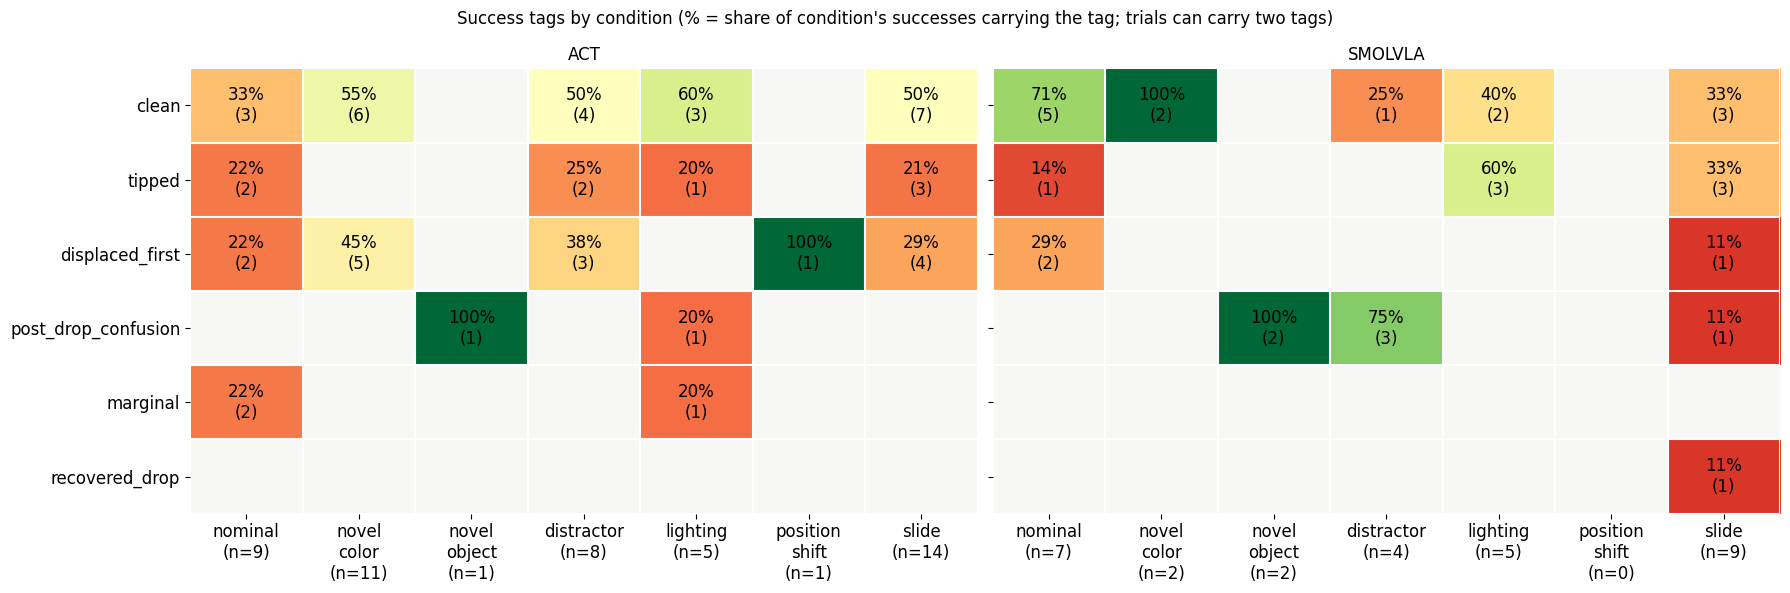

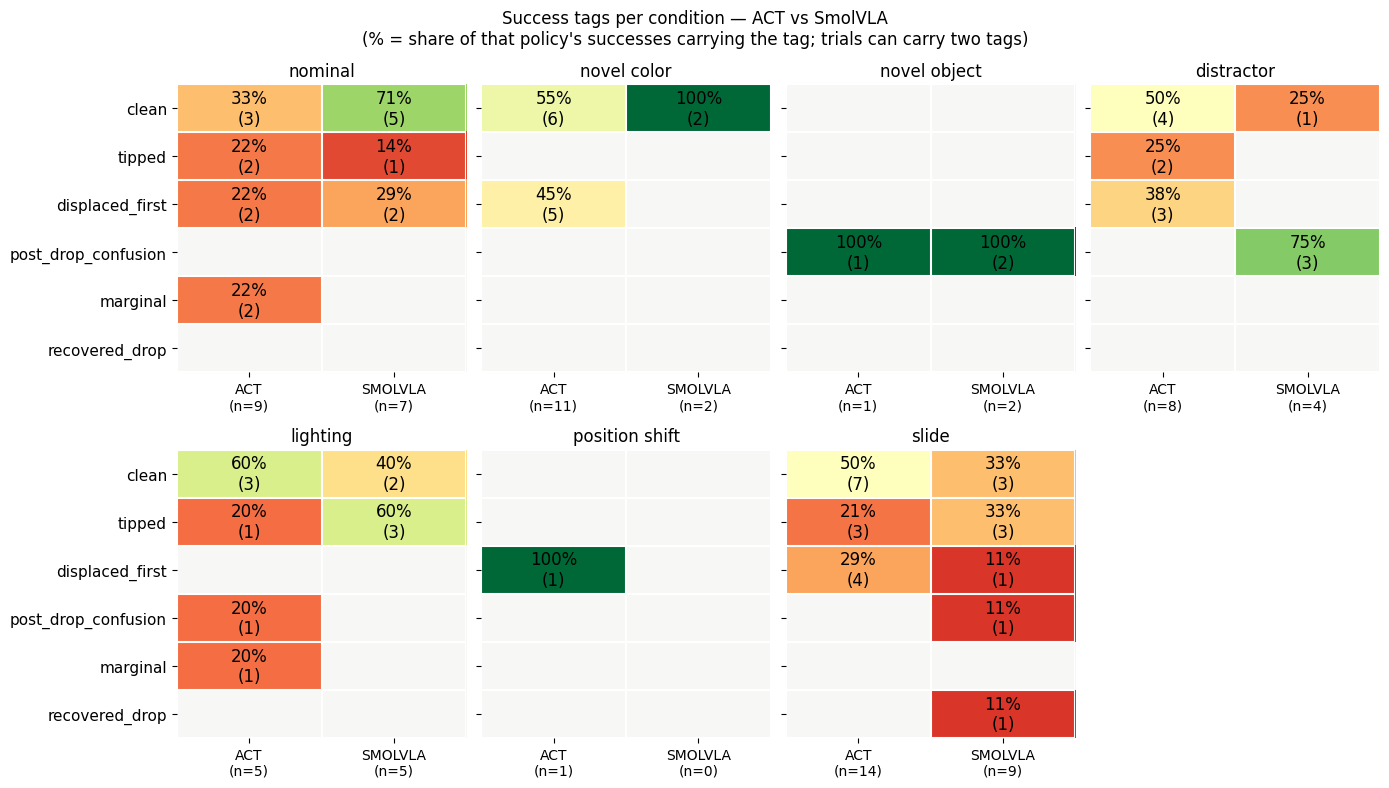

In [18]:
# ================= Success-TAG figures (tags are qualifiers, can overlap) ====
ROWS_T = ["clean", "tipped", "displaced_first", "post_drop_confusion",
          "marginal", "recovered_drop"]
CMAP_T = plt.get_cmap("RdYlGn").copy()     
CMAP_T.set_bad("#f7f7f5")

# explode tags: one row per (trial, tag)
succ_t = (succ.assign(tag=succ["trial_id"].map(SUCCESS_TAG))
              .explode("tag"))

def panel_data_t(sub):
    counts = sub.groupby(["condition", "tag"]).size().unstack(fill_value=0)
    counts = counts.reindex(index=CONDS, columns=ROWS_T, fill_value=0).T   # rows x conds
    # denominator = number of SUCCESSES in the condition (not tag rows),
    # so cells read "X% of this condition's successes carried this tag";
    # columns can sum >100% because trials can carry two tags.
    n_succ = sub.drop_duplicates("trial_id").groupby("condition").size().reindex(CONDS).fillna(0)
    share = counts / n_succ.replace(0, np.nan)
    return counts, share, n_succ

# ---------- Figure T1: per-policy tag fingerprint ----------
fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor="white")
for ax, pol in zip(axes, ["act", "smolvla"]):
    counts, share, n_succ = panel_data_t(succ_t[succ_t["policy"] == pol])
    ax.imshow(masked(share), cmap=CMAP_T, vmin=0, vmax=1, aspect="auto")
    annotate(ax, counts, share, fontsize=12)
    ax.set_xticks(range(len(CONDS)),
                  [f"{c.replace('_', chr(10))}\n(n={int(n_succ.iloc[j])})"
                   for j, c in enumerate(CONDS)], fontsize=12)
    ax.set_yticks(range(len(ROWS_T)), ROWS_T if pol == "act" else [""] * len(ROWS_T), fontsize=12)
    ax.set_xticks(np.arange(-0.5, len(CONDS)), minor=True)
    ax.set_yticks(np.arange(-0.5, len(ROWS_T)), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", length=0)
    ax.set_title(pol.upper(), fontsize=12)
    ax.spines[:].set_visible(False)
fig.suptitle("Success tags by condition (% = share of condition's successes carrying the tag; "
             "trials can carry two tags)", fontsize=12)
plt.tight_layout()
plt.savefig("success_tags_by_policy.png", dpi=200, bbox_inches="tight")
plt.show()

# ---------- Figure T2: per-condition panels ----------
fig, axes = plt.subplots(2, 4, figsize=(14, 8), facecolor="white")
axes = axes.ravel()
for k, cond in enumerate(CONDS):
    ax = axes[k]
    sub = succ_t[succ_t["condition"] == cond]
    counts = sub.groupby(["tag", "policy"]).size().unstack(fill_value=0)
    counts = counts.reindex(index=ROWS_T, columns=["act", "smolvla"], fill_value=0)
    n_succ = (sub.drop_duplicates("trial_id").groupby("policy").size()
                 .reindex(["act", "smolvla"]).fillna(0))
    share = counts / n_succ.replace(0, np.nan)
    ax.imshow(masked(share), cmap=CMAP_T, vmin=0, vmax=1, aspect="auto")
    annotate(ax, counts, share, fontsize=12)
    ax.set_xticks([0, 1],
                  [f"ACT\n(n={int(n_succ['act'])})",
                   f"SMOLVLA\n(n={int(n_succ['smolvla'])})"], fontsize=10)
    show_labels = (k % 4 == 0)
    ax.set_yticks(range(len(ROWS_T)), ROWS_T if show_labels else [""] * len(ROWS_T), fontsize=11)
    ax.set_xticks(np.arange(-0.5, 2), minor=True)
    ax.set_yticks(np.arange(-0.5, len(ROWS_T)), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", length=0)
    ax.set_title(cond.replace("_", " "), fontsize=12)
    ax.spines[:].set_visible(False)
axes[7].axis("off")
fig.suptitle("Success tags per condition — ACT vs SmolVLA\n"
             "(% = share of that policy's successes carrying the tag; trials can carry two tags)",
             fontsize=12)
plt.tight_layout()
plt.savefig("success_tags_per_condition.png", dpi=200, bbox_inches="tight")
plt.show()

In [35]:
import pandas as pd
import numpy as np

# =============================================================================
# Attempt coding from failure notes + success modes.
# Definition (frozen before coding): 1 attempt = one descend-toward-target +
# grasp-intent cycle, INCLUDING "phantom" attempts at empty locations
# (e.g. grasping at the demo middle). Hover/oscillation with no descend = 0.
# Rules, applied identically to both policies:
#   explicit count in note ("3 attempts", "on 2nd") -> that number
#   "multiple / kept / around / following attempts / few" -> 3 (floor)
#   repeated-targeting description without count -> 2 (floor)
#   single event ("tipped on first try", clean success) -> 1
#   hover-only note -> 0
#   empty-note failures (242, 271) -> NaN (video only)
# Successes inherit their mode: clean/tipped_first=1, second=2, third_plus=3.
# All vague codes are FLOORS -> attempts/episode is a lower bound.
# =============================================================================
ATTEMPTS = {
 1:3,2:2,3:3,4:2,5:0,6:0,7:0,8:1,9:2,10:2,11:0,12:2,13:0,14:0,15:0,16:0,
 17:3,18:2,19:2,20:2,21:2,22:2,23:2,24:2,25:2,26:2,27:3,28:3,29:2,30:1,31:1,32:1,
 33:1,34:2,35:2,36:2,37:2,38:1,39:3,40:1,41:1,42:1,43:1,44:2,45:2,46:2,47:2,48:1,
 49:3,50:1,51:2,52:1,
 53:1,54:2,55:2,56:2,57:2,58:1,59:2,60:1,61:2,62:2,63:2,64:2,65:2,66:2,67:2,68:2,
 69:1,70:2,71:2,72:0,
 73:1,74:3,75:3,76:3,77:1,78:1,79:3,80:2,81:1,82:3,83:3,84:1,85:1,86:0,87:0,88:1,
 89:1,90:1,91:2,92:2,
 93:1,94:3,95:3,96:2,97:2,98:2,99:2,100:2,101:1,102:1,103:2,104:2,105:2,106:2,
 107:2,108:1,109:2,110:2,111:2,112:2,
 113:1,114:1,115:2,116:2,117:1,118:1,119:2,120:1,121:3,122:1,123:3,124:1,125:2,
 126:0,127:0,128:1,129:1,130:3,131:1,132:1,
 133:1,134:1,135:2,136:1,137:2,138:1,139:2,140:1,141:1,142:1,143:2,144:2,145:2,
 146:2,147:2,148:1,149:1,150:2,151:2,152:2,
 153:2,154:2,155:2,156:0,157:0,158:1,159:2,160:2,161:2,162:2,163:2,164:2,165:2,
 166:2,167:2,168:2,169:2,170:2,171:0,172:0,
 173:1,174:1,175:2,176:2,177:3,178:3,179:3,180:3,181:2,182:2,183:2,184:3,185:3,
 186:2,187:2,188:2,189:2,190:2,191:2,192:3,
 193:1,194:2,195:2,196:3,197:1,198:2,199:1,200:2,201:2,202:1,203:2,204:1,205:3,
 206:3,207:3,208:1,209:1,210:3,211:1,212:2,
 213:1,214:1,215:1,216:2,217:2,218:1,219:2,220:2,221:3,222:1,223:1,224:3,225:2,
 226:2,227:2,228:1,229:2,230:2,231:3,232:2,
 233:1,234:1,235:3,236:1,237:3,238:1,239:3,240:3,241:1,242:np.nan,243:3,244:3,
 245:3,246:3,247:2,248:2,249:2,250:2,251:2,252:1,
 253:1,254:2,255:2,256:2,257:2,258:1,259:2,260:3,261:2,262:2,263:1,264:2,265:2,
 266:2,267:2,268:1,269:2,270:1,271:np.nan,272:1,
}

df = pd.read_excel(data_path)              # your path variable
df["attempts"] = df["trial_id"].map(ATTEMPTS)

assert len(ATTEMPTS) == 272

# "coded" = trials with a usable attempt count (drops the 2 NaN empty-note failures)
coded = df[df["attempts"].notna()]

print("=== attempts/episode (all coded trials, incl. hover-only zeros) ===")
print(coded.groupby("policy")["attempts"].agg(["mean", "sum", "count"]).round(2))

print("\n=== zero-attempt (hover-only) episodes ===")
print(coded[coded["attempts"] == 0].groupby("policy").size())

# engaged episodes only (>=1 grasp cycle) — the 1.84 vs 1.86 numbers
sub = coded[coded["attempts"] > 0]
t = sub.groupby("policy").agg(successes=("success", "sum"),
                              attempts=("attempts", "sum"),
                              episodes=("success", "count"))
t["succ_per_attempt"] = (t["successes"] / t["attempts"]).round(3)
t["attempts_per_ep"] = (t["attempts"] / t["episodes"]).round(2)
print("\n=== engaged episodes: throughput + conversion ===")
print(t)

print("\n=== same, excluding position_shift ===")
sub2 = sub[sub["condition"] != "position_shift"]
t2 = sub2.groupby("policy").agg(successes=("success", "sum"),
                                attempts=("attempts", "sum"),
                                episodes=("success", "count"))
t2["succ_per_attempt"] = (t2["successes"] / t2["attempts"]).round(3)
t2["attempts_per_ep"] = (t2["attempts"] / t2["episodes"]).round(2)
print(t2)

# --- the two skepticism checks from the discussion ---
print("\n=== attempt-count distribution (is the 3-cap binding?) ===")
print(pd.crosstab(sub["policy"], sub["attempts"]))

print("\n=== failure episodes only (both had full 30s) ===")
f = sub[sub["success"] == 0]
print(f.groupby("policy")["attempts"].agg(["mean", "count"]).round(2))


# failure episodes only, engaged (>=1 attempt) — both policies had the full 30s
f = coded[(coded["attempts"] > 0) & (coded["success"] == 0)]

print("=== attempts on FAILED episodes ===")
print(f.groupby("policy")["attempts"].agg(["mean", "count"]).round(2))

print("\n=== distribution of attempts (failed episodes) ===")
print(pd.crosstab(f["policy"], f["attempts"]))

# and the complement, for the first-attempt-success point:
s = coded[coded["success"] == 1]
print("\n=== successes by attempt number ===")
print(pd.crosstab(s["policy"], s["attempts"]))

=== attempts/episode (all coded trials, incl. hover-only zeros) ===
         mean    sum  count
policy                     
act      1.62  219.0    135
smolvla  1.84  249.0    135

=== zero-attempt (hover-only) episodes ===
policy
act        16
smolvla     1
dtype: int64

=== engaged episodes: throughput + conversion ===
         successes  attempts  episodes  succ_per_attempt  attempts_per_ep
policy                                                                   
act             49     219.0       119             0.224             1.84
smolvla         29     249.0       134             0.116             1.86

=== same, excluding position_shift ===
         successes  attempts  episodes  succ_per_attempt  attempts_per_ep
policy                                                                   
act             48     202.0       111             0.238             1.82
smolvla         29     217.0       118             0.134             1.84

=== attempt-count distribution (is the 3-cap

In [45]:
# Clearly above doesn't work super well (success numbers look different from what i got when i was looking at the data myself)
### So let's look at the action space of the robot - we know position of shoulder pan when it is oriented towards start region
### and what it is when it is oriented towards tray region. So by checking the number of passes between these we can measure attempts

import pandas as pd, numpy as np
from pathlib import Path

ROOT = Path.home() / ".cache/huggingface/lerobot/TamaraSumarac"

# repo per condition x policy + the two nominals
REPOS = {
    ("act", "nominal"):            "rollout_act_nominal_eval_20260818_104621",
    ("act", "novel_color"):        "rollout_eval_novel_color_act",
    ("act", "novel_object"):       "rollout_eval_novel_object_act",
    ("act", "distractor"):         "rollout_eval_distractor_act",
    ("act", "lighting"):           "rollout_eval_lighting_act",
    ("act", "position_shift"):     "rollout_eval_position_shift_act",
    ("act", "slide"):              "rollout_eval_slide_act",
    ("smolvla", "nominal"):        "rollout_smolvla_nominal_eval_20260824_084125",
    ("smolvla", "novel_color"):    "rollout_eval_novel_color_smolvla",
    ("smolvla", "novel_object"):   "rollout_eval_novel_object_smolvla",
    ("smolvla", "distractor"):     "rollout_eval_distractor_smolvla",
    ("smolvla", "lighting"):       "rollout_eval_lighting_smolvla",
    ("smolvla", "position_shift"): "rollout_eval_position_shift_smolvla",
    ("smolvla", "slide"):          "rollout_eval_slide_smolvla",
}

PAN_ENTER, PAN_EXIT = 35.0, 20.0   # hysteresis on shoulder_pan (deg)
GRIP_CLOSED = 20.0 #8.0                   # gripper below this during a visit = grasp attempt
MIN_VISIT_FRAMES = 10               # ignore blips < ~0.3s

def count_attempts(pan, grip):
    visits, grasps = 0, 0
    inside, start = False, 0
    for i in range(len(pan)):
        if not inside and pan[i] > PAN_ENTER:
            inside, start = True, i
        elif inside and pan[i] < PAN_EXIT:
            if i - start >= MIN_VISIT_FRAMES:
                visits += 1
                if grip[start:i].min() < GRIP_CLOSED:
                    grasps += 1
            inside = False
    if inside and len(pan) - start >= MIN_VISIT_FRAMES:   # episode ends mid-visit
        visits += 1
        if grip[start:].min() < GRIP_CLOSED:
            grasps += 1
    return visits, grasps

def resolve(repo_base):
    hits = sorted(ROOT.glob(repo_base + "*"))
    hits = [h for h in hits if h.is_dir()]
    if not hits:
        raise FileNotFoundError(f"no dataset dir matching {repo_base}*")
    if len(hits) > 1:
        print(f"WARNING: multiple matches for {repo_base}: {[h.name for h in hits]} — using {hits[-1].name}")
    return hits[-1]          # latest timestamp if several

rows = []
for (policy, cond), repo in REPOS.items():
    repo_dir = resolve(repo)
    pqs = sorted((repo_dir / "data").rglob("*.parquet"))
    if not pqs:
        raise FileNotFoundError(f"no parquet under {repo_dir}")
    for pq in pqs:
        d = pd.read_parquet(pq)
        for ep, g in d.groupby("episode_index"):
            # SmolVLA grid datasets: episode 0 is the compile warm-up, not a scored trial
            if policy == "smolvla" and cond != "nominal" and ep == 0:
                continue
            st = np.stack(g["observation.state"].to_numpy())
            v, a = count_attempts(st[:, 0], st[:, 5])
            rows.append(dict(policy=policy, condition=cond, episode_index=int(ep),
                             visits=v, grasp_attempts=a, frames=len(g)))

att = pd.DataFrame(rows)
print(att.groupby(["policy"])[["visits", "grasp_attempts"]].mean().round(2))
print(att.groupby(["policy", "condition"])[["visits", "grasp_attempts"]].mean().round(2))

# sanity: episode counts per cell should read 20/20/20/20/20/16 (+nominal 20)
# print(att.groupby(["policy", "condition"]).size())

         visits  grasp_attempts
policy                         
act        2.17            2.04
smolvla    1.57            1.51
                        visits  grasp_attempts
policy  condition                             
act     distractor        2.30            2.20
        lighting          2.40            2.30
        nominal           2.25            2.20
        novel_color       2.10            1.85
        novel_object      1.60            1.60
        position_shift    2.62            2.12
        slide             2.00            2.00
smolvla distractor        1.65            1.65
        lighting          1.60            1.60
        nominal           1.25            1.25
        novel_color       1.90            1.80
        novel_object      1.65            1.60
        position_shift    1.38            1.19
        slide             1.50            1.45


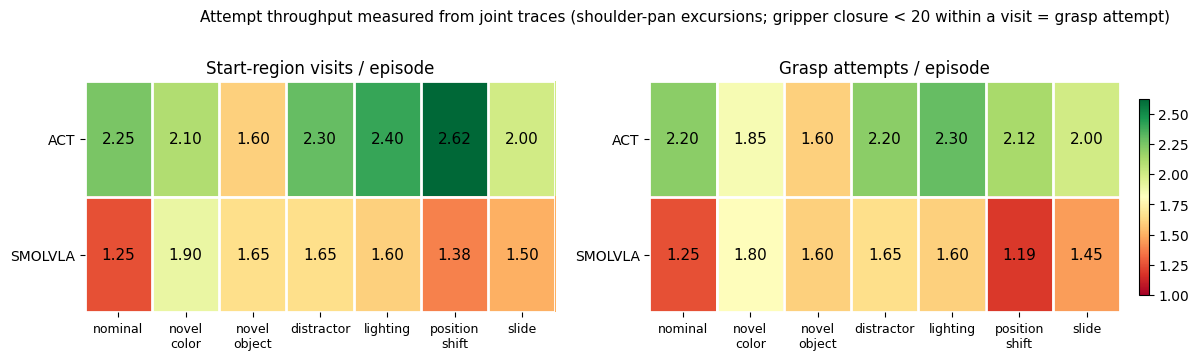

In [47]:
# Paired heatmap: visits + grasp attempts per episode, 2 policies x 7 conditions.
# Assumes `att` DataFrame from the trace-based counter is in scope.
import numpy as np
import matplotlib.pyplot as plt

CONDS = ["nominal", "novel_color", "novel_object", "distractor",
         "lighting", "position_shift", "slide"]
POLICIES = ["act", "smolvla"]

def pivot(metric):
    p = att.groupby(["policy", "condition"])[metric].mean().unstack()
    return p.reindex(index=POLICIES, columns=CONDS)

vis, gra = pivot("visits"), pivot("grasp_attempts")
vmax = float(max(vis.max().max(), gra.max().max()))   # one shared scale

CMAP = plt.get_cmap("RdYlGn").copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 3.0), facecolor="white")
for ax, data, title in zip(axes, [vis, gra],
                           ["Start-region visits / episode",
                            "Grasp attempts / episode"]):
    im = ax.imshow(data.to_numpy(), cmap=CMAP, vmin=1, vmax=vmax, aspect="auto")
    for i in range(len(POLICIES)):
        for j in range(len(CONDS)):
            ax.text(j, i, f"{data.iloc[i, j]:.2f}", ha="center", va="center",
                    fontsize=11, color="black")
    ax.set_xticks(range(len(CONDS)), [c.replace("_", "\n") for c in CONDS], fontsize=9)
    ax.set_yticks(range(len(POLICIES)), [p.upper() for p in POLICIES], fontsize=10)
    ax.set_xticks(np.arange(-0.5, len(CONDS)), minor=True)
    ax.set_yticks(np.arange(-0.5, len(POLICIES)), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", length=0)
    ax.set_title(title, fontsize=12)
    ax.spines[:].set_visible(False)
fig.colorbar(im, ax=axes, shrink=0.85, pad=0.015)
fig.suptitle("Attempt throughput measured from joint traces (shoulder-pan excursions; "
             "gripper closure < 20 within a visit = grasp attempt)",
             fontsize=11, y=1.12)
plt.savefig("attempts_per_episode.png", dpi=200, bbox_inches="tight")
plt.show()